# Student Performance Prediction
AIML Summer Internship 2026 - MNNIT Allahabad

## Step 1 - Import Libraries

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import pickle
import warnings
warnings.filterwarnings('ignore')

print('Libraries imported')

Libraries imported


## Step 2 - Load the Dataset

In [62]:
df = pd.read_csv('../Dataset/student_performance_updated_1000.csv')

print('Shape of dataset:', df.shape)
df.head()

Shape of dataset: (1000, 12)


,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Attendance (%),Online Classes Taken
0,1.0,John,Male,85.0,15.0,78.0,1.0,High,80.0,4.8,59.0,False
1,2.0,Sarah,Female,90.0,20.0,85.0,2.0,Medium,87.0,2.2,70.0,True
2,3.0,Alex,Male,78.0,10.0,65.0,0.0,Low,68.0,4.6,92.0,False
3,4.0,Michael,Male,92.0,25.0,90.0,3.0,High,92.0,2.9,96.0,False
4,5.0,Emma,Female,NaN,18.0,82.0,2.0,Medium,85.0,4.1,97.0,True


In [63]:
# check column names and data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  960 non-null    float64
 1   Name                       966 non-null    str    
 2   Gender                     952 non-null    str    
 3   AttendanceRate             960 non-null    float64
 4   StudyHoursPerWeek          950 non-null    float64
 5   PreviousGrade              967 non-null    float64
 6   ExtracurricularActivities  957 non-null    float64
 7   ParentalSupport            978 non-null    str    
 8   FinalGrade                 960 non-null    float64
 9   Study Hours                976 non-null    float64
 10  Attendance (%)             959 non-null    float64
 11  Online Classes Taken       975 non-null    object 
dtypes: float64(8), object(1), str(3)
memory usage: 115.5+ KB


In [64]:
# basic statistics
df.describe()

,StudentID,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,FinalGrade,Study Hours,Attendance (%)
count,960.000000,960.000000,950.000000,967.000000,957.000000,960.000000,976.000000,959.000000
mean,5416.019792,85.510417,17.630526,77.598759,1.520376,80.030208,2.406967,77.248175
std,2653.748319,7.332125,6.272132,10.006640,1.046439,9.493652,1.620267,19.298148
min,1.000000,70.000000,8.000000,60.000000,0.000000,62.000000,-5.000000,50.000000
25%,3113.500000,82.000000,12.000000,70.000000,1.000000,72.000000,1.200000,63.000000
50%,5396.500000,88.000000,18.000000,78.000000,1.000000,80.000000,2.500000,76.000000
75%,7754.750000,91.000000,22.000000,86.000000,2.000000,88.000000,3.700000,89.000000
max,9998.000000,95.000000,30.000000,90.000000,3.000000,92.000000,5.000000,200.000000


## Step 3 - Data Preprocessing

In [65]:
# check missing values
print('Missing values in each column:')
print(df.isnull().sum())

Missing values in each column:
StudentID                    40
Name                         34
Gender                       48
AttendanceRate               40
StudyHoursPerWeek            50
PreviousGrade                33
ExtracurricularActivities    43
ParentalSupport              22
FinalGrade                   40
Study Hours                  24
Attendance (%)               41
Online Classes Taken         25
dtype: int64


In [66]:
# drop columns that are not useful for prediction
df.drop(columns=['StudentID', 'Name'], inplace=True)

# drop duplicate columns
df.drop(columns=['Study Hours', 'Attendance (%)'], inplace=True)

print('Columns now:', list(df.columns))

Columns now: ['Gender', 'AttendanceRate', 'StudyHoursPerWeek', 'PreviousGrade', 'ExtracurricularActivities', 'ParentalSupport', 'FinalGrade', 'Online Classes Taken']


In [67]:
# fill missing values
# for number columns use median
df['AttendanceRate'].fillna(df['AttendanceRate'].median(), inplace=True)
df['StudyHoursPerWeek'].fillna(df['StudyHoursPerWeek'].median(), inplace=True)
df['PreviousGrade'].fillna(df['PreviousGrade'].median(), inplace=True)
df['ExtracurricularActivities'].fillna(df['ExtracurricularActivities'].median(), inplace=True)
df['FinalGrade'].fillna(df['FinalGrade'].median(), inplace=True)

# for text columns use mode
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
df['ParentalSupport'].fillna(df['ParentalSupport'].mode()[0], inplace=True)
df['Online Classes Taken'].fillna(df['Online Classes Taken'].mode()[0], inplace=True)

print('Missing values after filling:')
print(df.isnull().sum())

Missing values after filling:
Gender                       48
AttendanceRate               40
StudyHoursPerWeek            50
PreviousGrade                33
ExtracurricularActivities    43
ParentalSupport              22
FinalGrade                   40
Online Classes Taken         25
dtype: int64


In [68]:
# remove duplicate rows
df.drop_duplicates(inplace=True)
print('Shape after removing duplicates:', df.shape)

Shape after removing duplicates: (1000, 8)


In [69]:
# fix invalid values found during EDA
# StudyHoursPerWeek had -5 which is not possible
df['StudyHoursPerWeek'] = df['StudyHoursPerWeek'].clip(lower=0)

# AttendanceRate had 200 which is not possible
df['AttendanceRate'] = df['AttendanceRate'].clip(upper=100)

print('Done fixing invalid values')

Done fixing invalid values


In [70]:
# encode categorical columns
le = LabelEncoder()

df['Gender'] = le.fit_transform(df['Gender'])

# parental support has order so we manually map it
df['ParentalSupport'] = df['ParentalSupport'].map({'Low': 0, 'Medium': 1, 'High': 2})

# convert True/False to 1/0
df['Online Classes Taken'] = df['Online Classes Taken'].fillna(False).astype(int)

print('After encoding:')
df.head()

After encoding:


,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Online Classes Taken
0,1,85.0,15.0,78.0,1.0,2.0,80.0,0
1,0,90.0,20.0,85.0,2.0,1.0,87.0,1
2,1,78.0,10.0,65.0,0.0,0.0,68.0,0
3,1,92.0,25.0,90.0,3.0,2.0,92.0,0
4,0,NaN,18.0,82.0,2.0,1.0,85.0,1


## Step 4 - Exploratory Data Analysis (EDA)

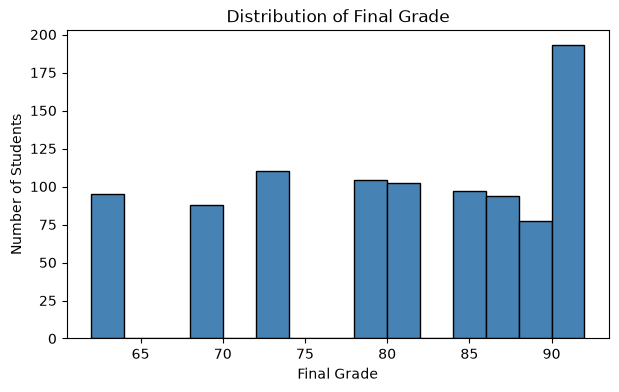

In [71]:
# distribution of final grade
plt.figure(figsize=(7, 4))
plt.hist(df['FinalGrade'], bins=15, color='steelblue', edgecolor='black')
plt.title('Distribution of Final Grade')
plt.xlabel('Final Grade')
plt.ylabel('Number of Students')
plt.show()

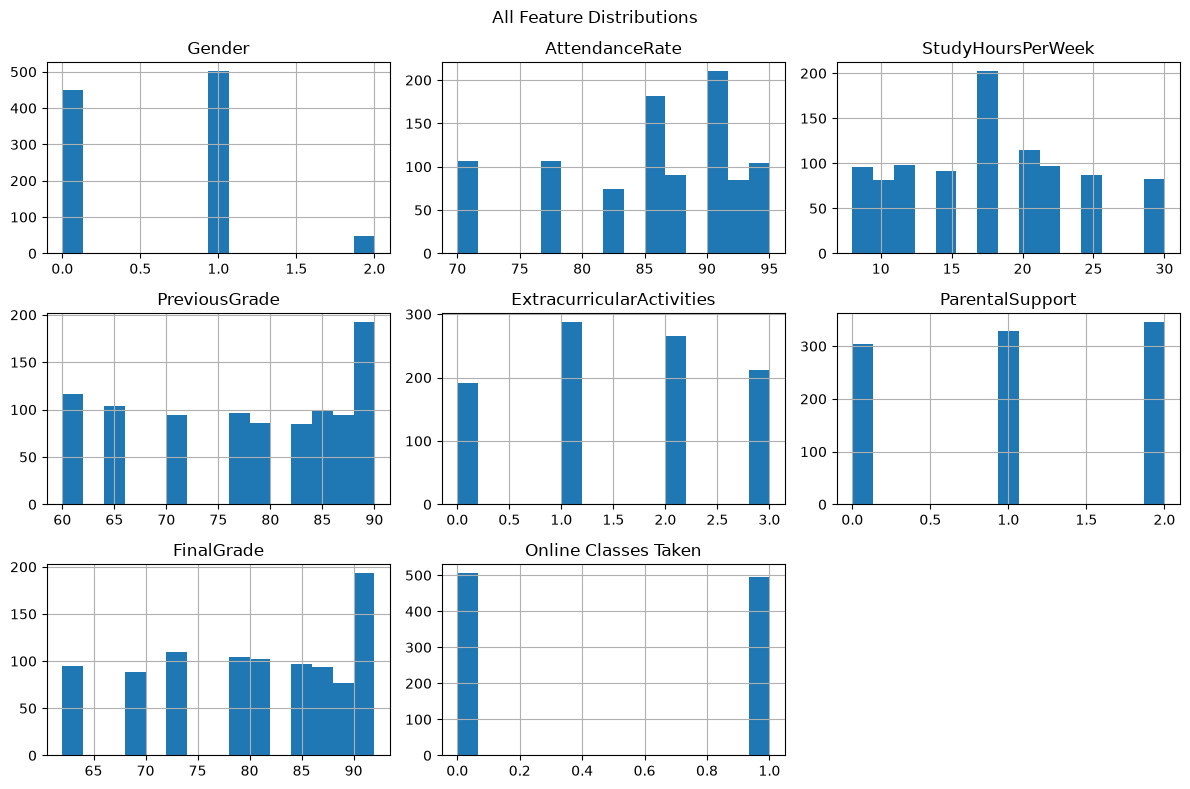

In [72]:
# histogram for all columns
df.hist(figsize=(12, 8), bins=15)
plt.suptitle('All Feature Distributions')
plt.tight_layout()
plt.show()

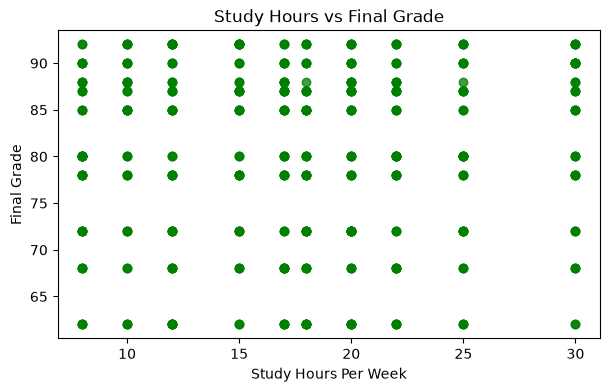

In [73]:
# scatter plot - study hours vs final grade
plt.figure(figsize=(7, 4))
plt.scatter(df['StudyHoursPerWeek'], df['FinalGrade'], alpha=0.5, color='green')
plt.title('Study Hours vs Final Grade')
plt.xlabel('Study Hours Per Week')
plt.ylabel('Final Grade')
plt.show()

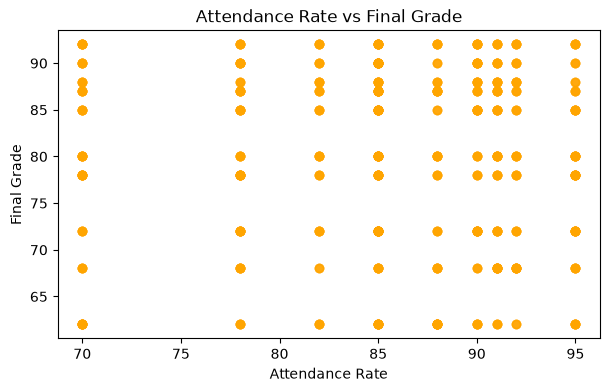

In [74]:
# scatter plot - attendance vs final grade
plt.figure(figsize=(7, 4))
plt.scatter(df['AttendanceRate'], df['FinalGrade'], alpha=0.5, color='orange')
plt.title('Attendance Rate vs Final Grade')
plt.xlabel('Attendance Rate')
plt.ylabel('Final Grade')
plt.show()

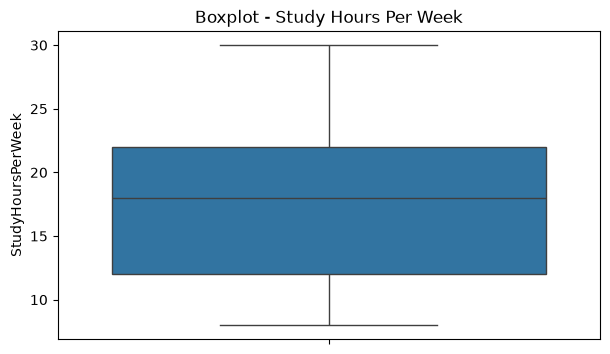

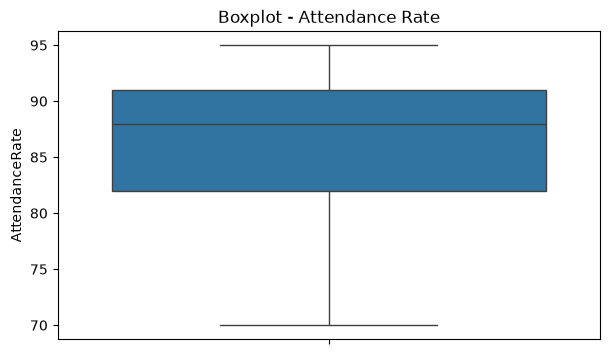

In [75]:
# boxplots to check outliers
plt.figure(figsize=(7, 4))
sns.boxplot(y=df['StudyHoursPerWeek'])
plt.title('Boxplot - Study Hours Per Week')
plt.show()

plt.figure(figsize=(7, 4))
sns.boxplot(y=df['AttendanceRate'])
plt.title('Boxplot - Attendance Rate')
plt.show()

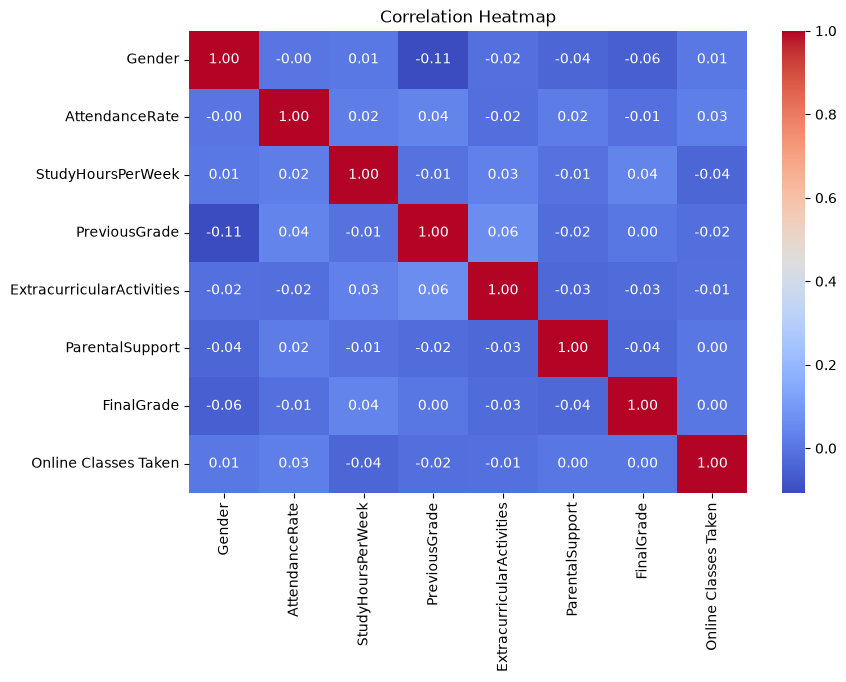

In [76]:
# heatmap to see correlation between features
plt.figure(figsize=(9, 6))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## Step 5 - Feature Engineering

In [77]:
# create a new feature combining attendance and study hours
df['AcademicIndex'] = df['AttendanceRate'] + df['StudyHoursPerWeek']

print('New feature AcademicIndex added')
df.head()

New feature AcademicIndex added


,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Online Classes Taken,AcademicIndex
0,1,85.0,15.0,78.0,1.0,2.0,80.0,0,100.0
1,0,90.0,20.0,85.0,2.0,1.0,87.0,1,110.0
2,1,78.0,10.0,65.0,0.0,0.0,68.0,0,88.0
3,1,92.0,25.0,90.0,3.0,2.0,92.0,0,117.0
4,0,NaN,18.0,82.0,2.0,1.0,85.0,1,NaN


## Step 6 - Model Building

In [78]:
# split data into features and target
X = df.drop(columns=['FinalGrade'])
y = df['FinalGrade']

print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (1000, 8)
y shape: (1000,)


In [79]:
# split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Training size:', X_train.shape[0])
print('Testing size:', X_test.shape[0])

Training size: 800
Testing size: 200


In [80]:
# make sure no NaN values remain before training
X = X.fillna(X.median())
y = y.fillna(y.median())

# redo the train test split after cleaning
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Any NaN in X_train:', X_train.isnull().sum().sum())
print('Any NaN in y_train:', y_train.isnull().sum())

Any NaN in X_train: 0
Any NaN in y_train: 0


In [81]:
# Model 1 - Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

print('Linear Regression trained')

Linear Regression trained


In [82]:
# Model 2 - Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print('Random Forest trained')

Random Forest trained


In [83]:
# Model 3 - XGBoost
xgb = XGBRegressor(n_estimators=100, random_state=42)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

print('XGBoost trained')

XGBoost trained


## Step 7 - Model Evaluation

In [84]:
# evaluate linear regression
print('--- Linear Regression ---')
print('MAE :', round(mean_absolute_error(y_test, lr_pred), 2))
print('RMSE:', round(np.sqrt(mean_squared_error(y_test, lr_pred)), 2))
print('R2  :', round(r2_score(y_test, lr_pred), 2))

--- Linear Regression ---
MAE : 8.06
RMSE: 9.57
R2  : -0.02


In [85]:
# evaluate random forest
print('--- Random Forest ---')
print('MAE :', round(mean_absolute_error(y_test, rf_pred), 2))
print('RMSE:', round(np.sqrt(mean_squared_error(y_test, rf_pred)), 2))
print('R2  :', round(r2_score(y_test, rf_pred), 2))

--- Random Forest ---
MAE : 8.66
RMSE: 10.33
R2  : -0.19


In [86]:
# evaluate xgboost
print('--- XGBoost ---')
print('MAE :', round(mean_absolute_error(y_test, xgb_pred), 2))
print('RMSE:', round(np.sqrt(mean_squared_error(y_test, xgb_pred)), 2))
print('R2  :', round(r2_score(y_test, xgb_pred), 2))

--- XGBoost ---
MAE : 9.71
RMSE: 11.87
R2  : -0.57


In [87]:
# compare all models in a table
results = {
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'MAE':  [round(mean_absolute_error(y_test, lr_pred), 2),
             round(mean_absolute_error(y_test, rf_pred), 2),
             round(mean_absolute_error(y_test, xgb_pred), 2)],
    'RMSE': [round(np.sqrt(mean_squared_error(y_test, lr_pred)), 2),
             round(np.sqrt(mean_squared_error(y_test, rf_pred)), 2),
             round(np.sqrt(mean_squared_error(y_test, xgb_pred)), 2)],
    'R2':   [round(r2_score(y_test, lr_pred), 2),
             round(r2_score(y_test, rf_pred), 2),
             round(r2_score(y_test, xgb_pred), 2)]
}

results_df = pd.DataFrame(results)
print(results_df)

               Model   MAE   RMSE    R2
0  Linear Regression  8.06   9.57 -0.02
1      Random Forest  8.66  10.33 -0.19
2            XGBoost  9.71  11.87 -0.57


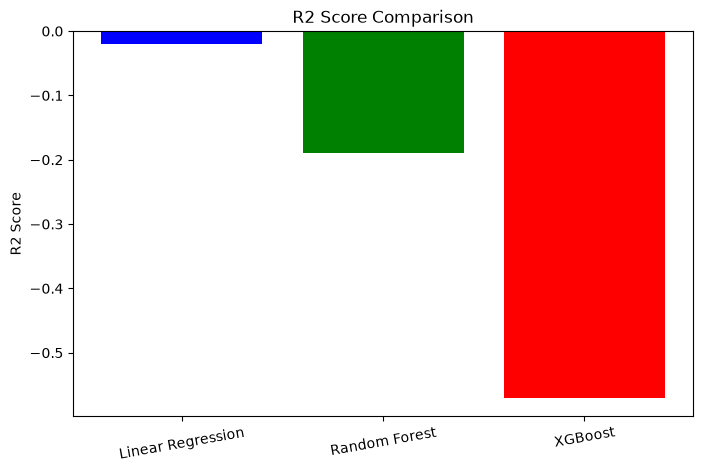

In [88]:
# plot comparison bar chart
plt.figure(figsize=(8, 5))
plt.bar(results_df['Model'], results_df['R2'], color=['blue', 'green', 'red'])
plt.title('R2 Score Comparison')
plt.ylabel('R2 Score')
plt.xticks(rotation=10)
plt.show()

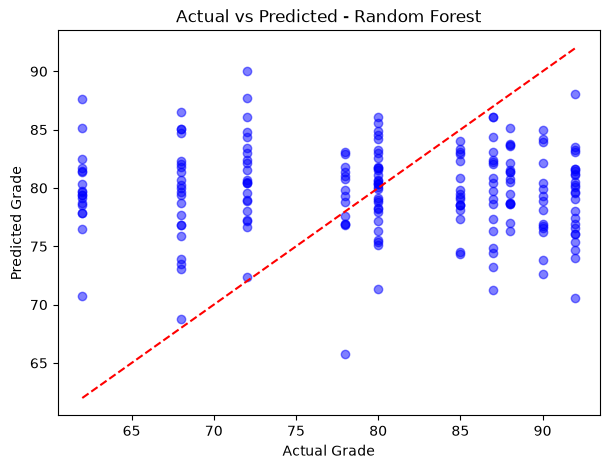

In [89]:
# actual vs predicted plot for random forest
plt.figure(figsize=(7, 5))
plt.scatter(y_test, rf_pred, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Actual vs Predicted - Random Forest')
plt.xlabel('Actual Grade')
plt.ylabel('Predicted Grade')
plt.show()

## Step 8 - Save the Best Model

In [90]:
# save the best model using pickle
# random forest gave highest R2 so saving that
with open('../Model/model.pkl', 'wb') as f:
    pickle.dump(rf, f)

# also save the feature column list for streamlit app
feature_cols = list(X.columns)
with open('../Model/features.pkl', 'wb') as f:
    pickle.dump(feature_cols, f)

print('Model saved')
print('Features:', feature_cols)

Model saved
Features: ['Gender', 'AttendanceRate', 'StudyHoursPerWeek', 'PreviousGrade', 'ExtracurricularActivities', 'ParentalSupport', 'Online Classes Taken', 'AcademicIndex']


In [91]:
# add some low performing student records to balance the dataset
import pandas as pd
import numpy as np

low_performers = pd.DataFrame({
    'Gender':                    [0, 1, 0, 1, 0, 1, 0, 1],
    'AttendanceRate':            [20, 15, 30, 10, 25, 18, 22, 12],
    'StudyHoursPerWeek':         [1,  0,  2,  0,  1,  0,  2,  1],
    'PreviousGrade':             [25, 20, 30, 15, 28, 22, 18, 24],
    'ExtracurricularActivities': [0,  0,  1,  0,  0,  1,  0,  0],
    'ParentalSupport':           [0,  0,  0,  1,  0,  0,  1,  0],
    'Online Classes Taken':      [0,  0,  0,  0,  1,  0,  0,  1],
    'AcademicIndex':             [21, 15, 32, 10, 26, 18, 24, 13],
    'FinalGrade':                [28, 22, 35, 18, 30, 25, 20, 26],
})

df = pd.concat([df, low_performers], ignore_index=True)
print("Dataset size after adding low performers:", df.shape)

Dataset size after adding low performers: (1008, 9)
